In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import re

In [2]:
# load the dataset
file_path = "h224.dta"
df_raw = pd.read_stata(file_path, convert_dates=False, convert_categoricals=False)

In [3]:
df_raw.head() # fetching top 5 rows

,DUID,PID,DUPERSID,PANEL,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,...,RXOSR20,RXPTR20,RXOTH20,PERWT20F,FAMWT20F,FAMWT20C,SAQWT20F,DIABW20F,VARSTR,VARPSU
0,2320005,101,2320005101,23,A,A,A,A,A,A,...,0,0,0,8418.417067,10019.765809,10019.765809,0.000000,0.0,2079,1
1,2320005,102,2320005102,23,A,A,A,A,A,A,...,0,0,0,5199.931866,10019.765809,10019.765809,0.000000,0.0,2079,1
2,2320006,101,2320006101,23,A,A,A,A,A,A,...,0,0,0,2139.840017,1646.585855,1646.585855,0.000000,0.0,2028,1
3,2320006,102,2320006102,23,B,B,B,B,B,B,...,0,0,0,2216.008686,2883.001611,2883.001611,4082.830163,0.0,2028,1
4,2320006,103,2320006103,23,A,A,A,A,A,A,...,0,0,0,4157.285889,1646.585855,1646.585855,0.000000,0.0,2028,1


In [4]:
df_raw.shape

(27805, 1451)

In [5]:
# Dataset information
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27805 entries, 0 to 27804
Columns: 1451 entries, DUID to VARPSU
dtypes: float64(20), int16(378), int32(211), int8(827), object(15)
memory usage: 71.8+ MB


In [6]:
# Select MEPS H224 variables relevant to claim approval
cols = {
    'AGE42X':   'AGE',
    'SEX':      'SEX',
    'RACETHX':  'RACE',
    'POVCAT20': 'INCOME_PCT_FPL',
    'INSCOV20': 'INSURANCE_TYPE',
    'TOTEXP20': 'TOTAL_EXPENDITURE',
    'EMPST42':  'EMPLOYED',
    'EDUCYR':   'EDUCATION',
    'REGION20': 'REGION',
    'OBTOTV20': 'NUM_CHRONIC',    # proxy: total office visits
}

df = df_raw[list(cols.keys())].rename(columns=cols)
print(df.shape)
print(df.isnull().sum())

(27805, 10)
AGE                  0
SEX                  0
RACE                 0
INCOME_PCT_FPL       0
INSURANCE_TYPE       0
TOTAL_EXPENDITURE    0
EMPLOYED             0
EDUCATION            0
REGION               0
NUM_CHRONIC          0
dtype: int64


In [7]:
# OBTOTV20 = total office-based visits (healthcare utilisation proxy)
cols = {
    'AGE42X':   'AGE',
    'SEX':      'SEX',
    'RACETHX':  'RACE',
    'POVCAT20': 'INCOME_PCT_FPL',
    'INSCOV20': 'INSURANCE_TYPE',
    'TOTEXP20': 'TOTAL_EXPENDITURE',
    'EMPST42':  'EMPLOYED',
    'EDUCYR':   'EDUCATION',
    'REGION20': 'REGION',
    'OBTOTV20': 'NUM_VISITS',   # ← correct column name (was 'NUM_CHRONIC' before — bug fixed)
}

df = df_raw[list(cols.keys())].rename(columns=cols).copy()
print("Selected shape:", df.shape)
print(df.isnull().sum())

Selected shape: (27805, 10)
AGE                  0
SEX                  0
RACE                 0
INCOME_PCT_FPL       0
INSURANCE_TYPE       0
TOTAL_EXPENDITURE    0
EMPLOYED             0
EDUCATION            0
REGION               0
NUM_VISITS           0
dtype: int64


In [8]:
# MEPS uses negative codes:
# -1 = Inapplicable, -7 = Refused, -8 = Don't know, -9 = Not ascertained
# Replace all negative values with NaN
df = df.map(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# Drop rows missing more than 30% of features
df = df.dropna(thresh=int(0.7 * df.shape[1]))

# Impute remaining NaNs with column median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

missing_pct = df.isnull().mean().round(3) * 100
print("\nMissing % per column after imputation:")
print(missing_pct[missing_pct > 0] if missing_pct.sum() > 0 else "None")
print("\nClean shape:", df.shape)

Duplicates removed: 289

Missing % per column after imputation:
None

Clean shape: (27512, 10)


In [9]:
# CLAIM_APPROVED = 1 if person has insurance AND recorded positive expenditure
df['CLAIM_APPROVED'] = (
    (df['INSURANCE_TYPE'].isin([1, 2, 3])) &
    (df['TOTAL_EXPENDITURE'] > 0)
).astype(int)

print("Approval rate:", df['CLAIM_APPROVED'].mean().round(3))
print(df['CLAIM_APPROVED'].value_counts())

Approval rate: 0.833
CLAIM_APPROVED
1    22911
0     4601
Name: count, dtype: int64


# EDA

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

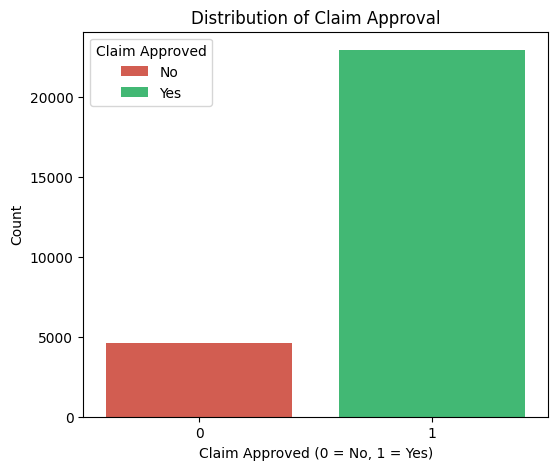

In [11]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x='CLAIM_APPROVED',
    hue='CLAIM_APPROVED', # Assign x to hue to remove warning
    data=df,
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Distribution of Claim Approval')
plt.xlabel('Claim Approved (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
new_labels = ['No', 'Yes']
ax.legend(handles=handles, labels=new_labels, title='Claim Approved')

plt.show()

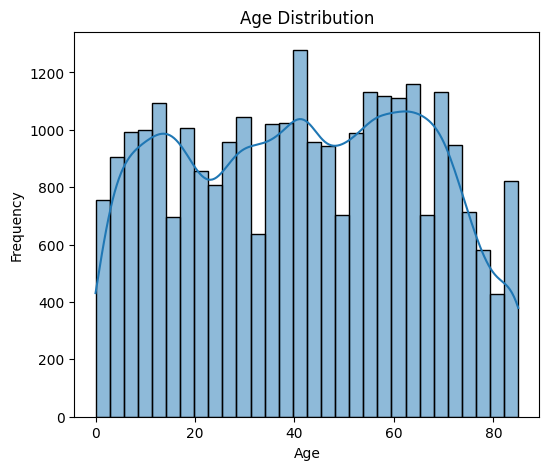

In [12]:
plt.figure(figsize=(6,5))

sns.histplot(
    df['AGE'].dropna(),
    bins=30,
    kde=True
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

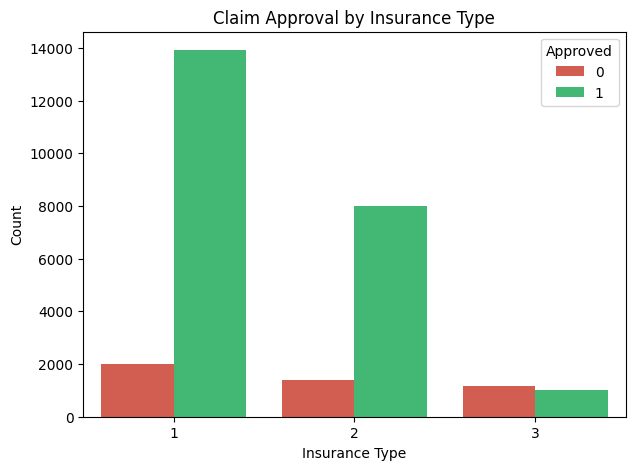

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='INSURANCE_TYPE',
    hue='CLAIM_APPROVED',
    data=df,
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Claim Approval by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Count')
plt.legend(title='Approved')

plt.show()

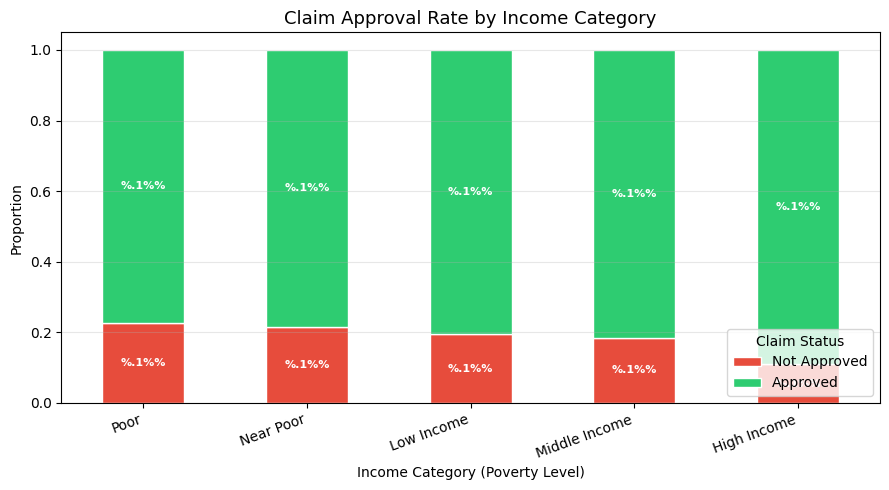

In [14]:
# Approval rate broken down by income poverty category
# INCOME_PCT_FPL: 1=Poor, 2=Near Poor, 3=Low Income, 4=Middle Income, 5=High Income

income_labels = {1: 'Poor', 2: 'Near Poor', 3: 'Low Income', 4: 'Middle Income', 5: 'High Income'}
df['INCOME_LABEL'] = df['INCOME_PCT_FPL'].map(income_labels)

income_approval = (
    df.groupby('INCOME_LABEL')['CLAIM_APPROVED']
    .value_counts(normalize=True)
    .unstack()
    .reindex(['Poor', 'Near Poor', 'Low Income', 'Middle Income', 'High Income'])
)

fig, ax = plt.subplots(figsize=(9, 5))
income_approval.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c', '#2ecc71'], edgecolor='white'
)

ax.set_title('Claim Approval Rate by Income Category', fontsize=13)
ax.set_xlabel('Income Category (Poverty Level)')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(['Not Approved', 'Approved'], title='Claim Status', loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on each bar segment
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.1%%', label_type='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Log-transform expenditure to reduce right skew
df['LOG_EXPENDITURE'] = np.log1p(df['TOTAL_EXPENDITURE'])

# Bin age into 5 groups: 0-30, 30-45, 45-60, 60-75, 75+
df['AGE_GROUP'] = pd.cut(
    df['AGE'], bins=[0, 30, 45, 60, 75, 100],
    labels=[1, 2, 3, 4, 5]
).astype(float)

# High utiliser: office visits above median
median_visits = df['NUM_VISITS'].median()
df['HIGH_UTILIZER'] = (df['NUM_VISITS'] > median_visits).astype(int)

# Interaction feature: insured AND employed (most stable coverage group)
df['INSURED_EMPLOYED'] = (
    (df['INSURANCE_TYPE'].isin([1, 2])) & (df['EMPLOYED'] == 1)
).astype(int)

# Drop original expenditure (replaced by log version)
df.drop(columns=['TOTAL_EXPENDITURE'], inplace=True)

print("Features after engineering:", df.shape[1])
print(df.head(3))

Features after engineering: 15
    AGE  SEX  RACE  INCOME_PCT_FPL  INSURANCE_TYPE  EMPLOYED  EDUCATION  \
0  73.0    2     2               2               2       4.0       14.0   
1  84.0    1     2               2               2       4.0       12.0   
2  46.0    2     1               3               3       4.0       12.0   

   REGION  NUM_VISITS  CLAIM_APPROVED INCOME_LABEL  LOG_EXPENDITURE  \
0     1.0           4               1    Near Poor         6.131226   
1     1.0           0               1    Near Poor         6.336826   
2     3.0           1               1   Low Income         4.948760   

   AGE_GROUP  HIGH_UTILIZER  INSURED_EMPLOYED  
0        4.0              1                 0  
1        5.0              0                 0  
2        3.0              0                 0  


In [16]:
# Drop leakage columns (payment/expenditure/charge codes)
leakage_pattern = re.compile(r'(EXP|PAY|CHG|CHARGE|PMT|PRPAY|MCDPAY|PRVPAY)', re.IGNORECASE)

# Drop ID-like columns
id_pattern = re.compile(r'^(DUID|PID|DUPERSID|CPSFAMID)$|FAMID', re.IGNORECASE)

drop_cols = set()
for col in df.columns:
    if col == 'CLAIM_APPROVED':
        continue
    if leakage_pattern.search(col) or id_pattern.search(col):
        drop_cols.add(col)

print(f"Dropping {len(drop_cols)} leakage/ID columns: {sorted(drop_cols)}")

X = df.drop(columns=list(drop_cols) + ['CLAIM_APPROVED'], errors='ignore')
X = X.select_dtypes(include='number')   # keep numeric columns only
y = df['CLAIM_APPROVED']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Dropping 1 leakage/ID columns: ['LOG_EXPENDITURE']
X shape: (27512, 12)
y distribution:
 CLAIM_APPROVED
1    22911
0     4601
Name: count, dtype: int64


# Train/Test

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, "  Test size:", X_test.shape)

Train size: (22009, 12)   Test size: (5503, 12)


In [19]:
results = []

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    pred  = pipeline.predict(X_te)
    proba = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    acc  = accuracy_score(y_te, pred)
    auc  = roc_auc_score(y_te, proba) if proba is not None else np.nan
    report = classification_report(y_te, pred, output_dict=True)
    f1   = report['weighted avg']['f1-score']
    prec = report['weighted avg']['precision']
    rec  = report['weighted avg']['recall']

    results.append({'Model': name, 'Accuracy': acc, 'AUC-ROC': auc,
                    'F1 (weighted)': f1, 'Precision': prec, 'Recall': rec})
    print(f"  {name} : ")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}" if not np.isnan(auc) else "  AUC-ROC  : N/A")
    print(f"  F1 (wtd) : {f1:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_te, pred))
    return pipeline, pred, proba

In [20]:

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression

In [21]:
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe, lr_pred, lr_proba = evaluate_model(
    'Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test
)

  Logistic Regression : 
  Accuracy : 0.8741
  AUC-ROC  : 0.9364
  F1 (wtd) : 0.8703

  Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.56      0.60       920
           1       0.91      0.94      0.93      4583

    accuracy                           0.87      5503
   macro avg       0.78      0.75      0.76      5503
weighted avg       0.87      0.87      0.87      5503



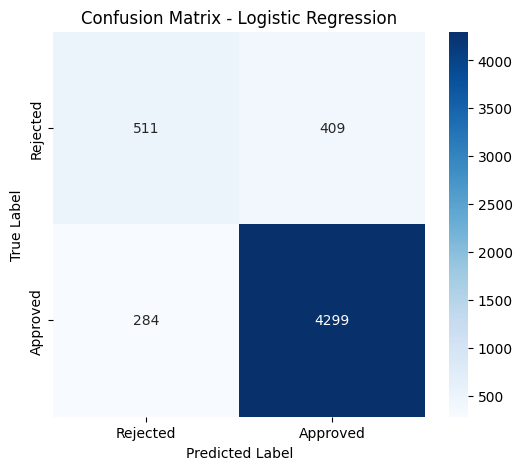

In [22]:

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Random Forest

In [23]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(n_estimators=200, max_depth=10,
                                       n_jobs=-1, random_state=42))
])
rf_pipe, rf_pred, rf_proba = evaluate_model(
    'Random Forest', rf_pipe, X_train, y_train, X_test, y_test
)

  Random Forest : 
  Accuracy : 0.8828
  AUC-ROC  : 0.9405
  F1 (wtd) : 0.8867

  Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.74      0.68       920
           1       0.95      0.91      0.93      4583

    accuracy                           0.88      5503
   macro avg       0.79      0.83      0.80      5503
weighted avg       0.89      0.88      0.89      5503



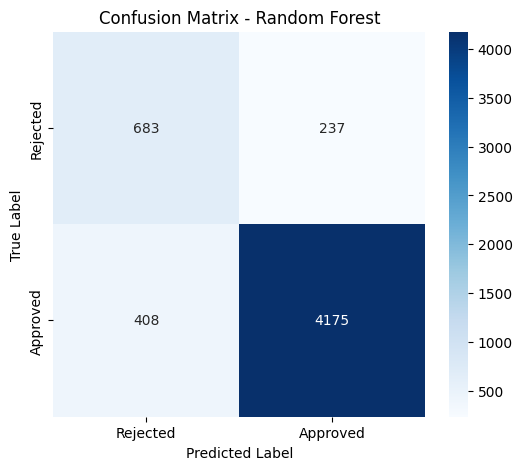

In [24]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Gradient Boosting

In [25]:
gb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                           max_depth=4, random_state=42))
])
gb_pipe, gb_pred, gb_proba = evaluate_model(
    'Gradient Boosting', gb_pipe, X_train, y_train, X_test, y_test
)

  Gradient Boosting : 
  Accuracy : 0.8848
  AUC-ROC  : 0.9394
  F1 (wtd) : 0.8882

  Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.74      0.68       920
           1       0.95      0.91      0.93      4583

    accuracy                           0.88      5503
   macro avg       0.79      0.83      0.81      5503
weighted avg       0.89      0.88      0.89      5503



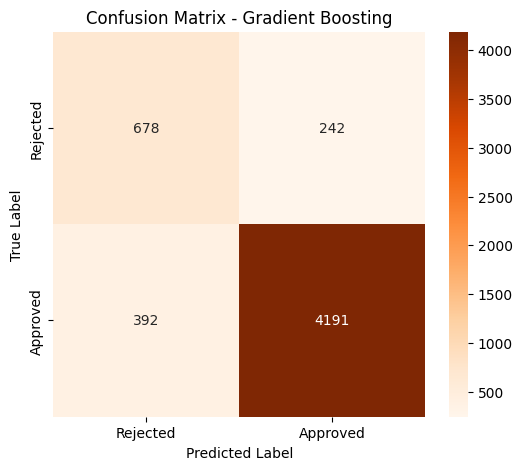

In [26]:
cm_gb = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Neural Network(MLP)

In [27]:
from sklearn.neural_network import MLPClassifier

In [28]:
# Neural Network (MLPClassifier)
mlp_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size=32,
        learning_rate='adaptive',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

mlp_pipe, mlp_pred, mlp_proba = evaluate_model(
    'Neural Network (MLP)', mlp_pipe, X_train, y_train, X_test, y_test
)

  Neural Network (MLP) : 
  Accuracy : 0.8802
  AUC-ROC  : 0.9378
  F1 (wtd) : 0.8834

  Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.72      0.67       920
           1       0.94      0.91      0.93      4583

    accuracy                           0.88      5503
   macro avg       0.78      0.81      0.80      5503
weighted avg       0.89      0.88      0.88      5503



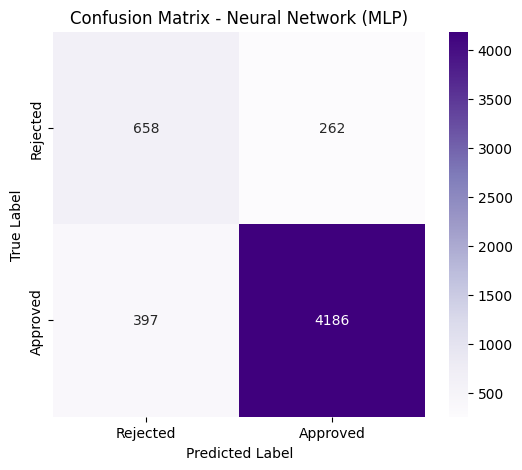

In [29]:
cm_mlp = confusion_matrix(y_test, mlp_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.title('Confusion Matrix - Neural Network (MLP)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model Comparision

In [30]:
results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results_df = results_df.round(4)

print("\nModel Comparison")
print(results_df.to_string(index=False))


Model Comparison
               Model  Accuracy  AUC-ROC  F1 (weighted)  Precision  Recall
       Random Forest    0.8828   0.9405         0.8867     0.8927  0.8828
   Gradient Boosting    0.8848   0.9394         0.8882     0.8933  0.8848
Neural Network (MLP)    0.8802   0.9378         0.8834     0.8880  0.8802
 Logistic Regression    0.8741   0.9364         0.8703     0.8679  0.8741


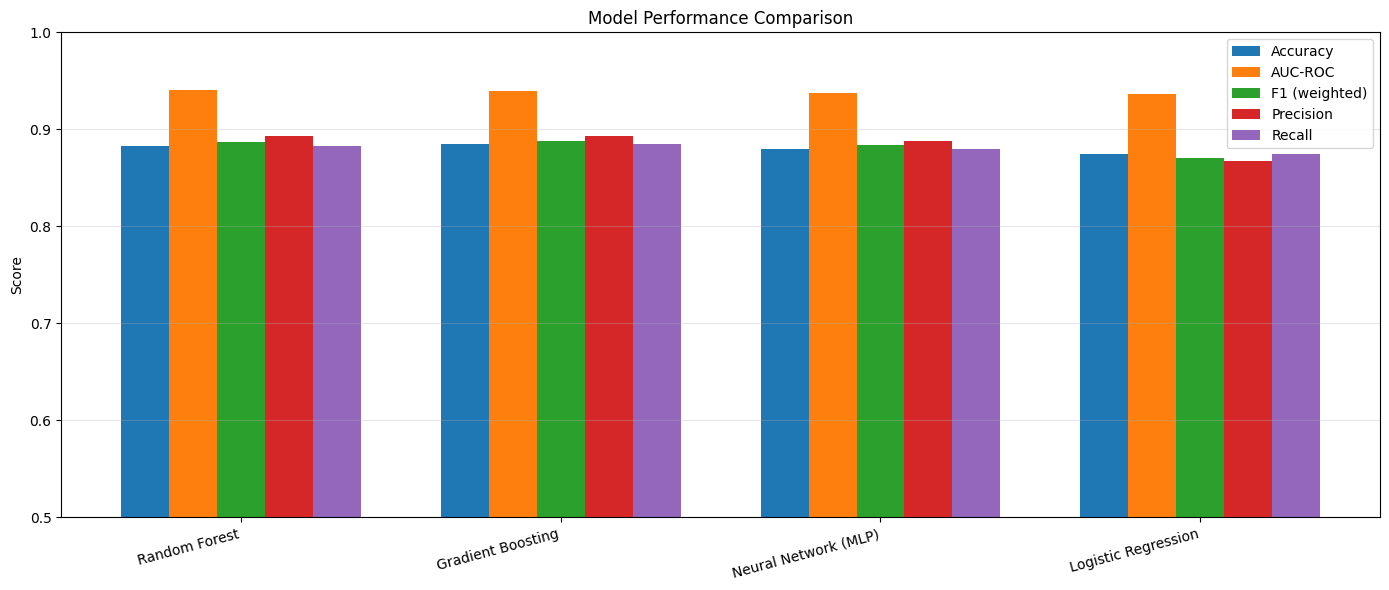

In [31]:
metrics = ['Accuracy', 'AUC-ROC', 'F1 (weighted)', 'Precision', 'Recall']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

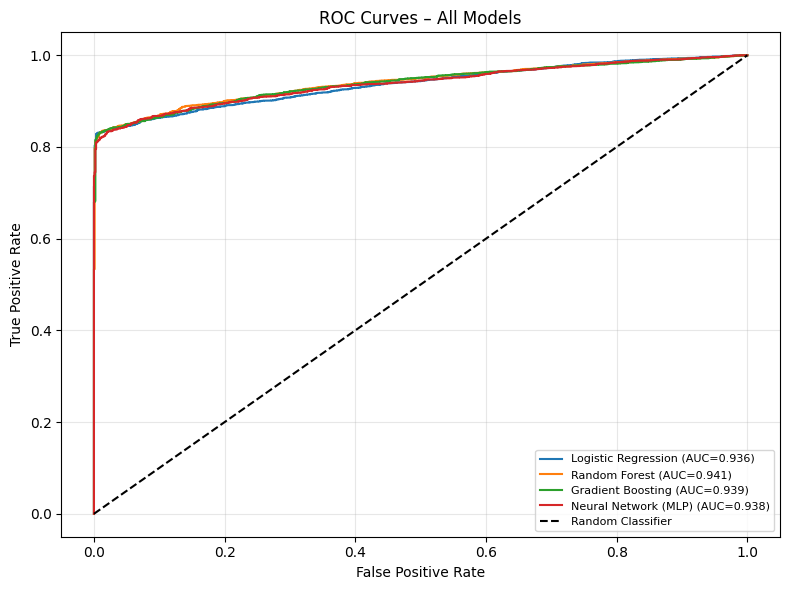

In [32]:
models_info = [
    ('Logistic Regression',  lr_proba),
    ('Random Forest',        rf_proba),
    ('Gradient Boosting',    gb_proba),
    ('Neural Network (MLP)', mlp_proba)
]

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in models_info:
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

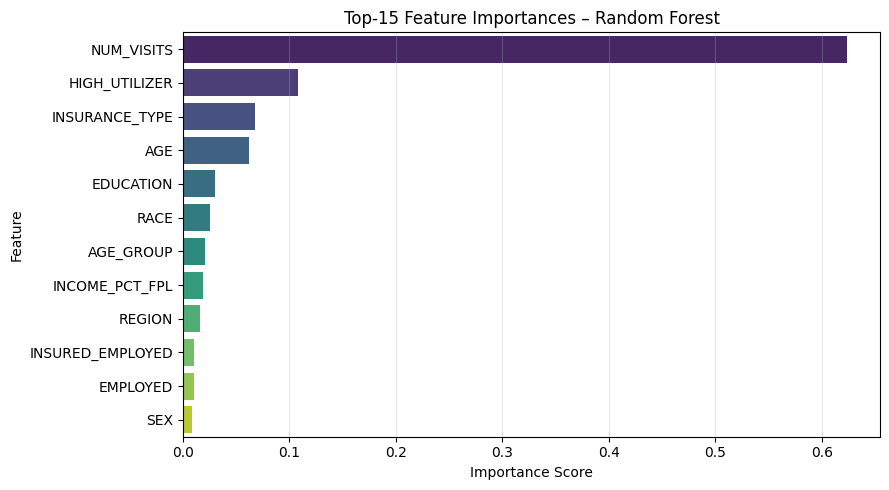

In [34]:
rf_model = rf_pipe.named_steps['model']
feat_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'Feature':    feat_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, palette='viridis', ax=ax, legend=False)
ax.set_title('Top-15 Feature Importances – Random Forest')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

rf_cv = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
cv_scores = cross_val_score(rf_cv, X_imputed, y, cv=5, scoring='roc_auc', n_jobs=-1)

for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean ± Std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

best = results_df.iloc[0]
print(f"  Best model  : {best['Model']}")
print(f"  Accuracy    : {best['Accuracy']:.4f}")
print(f"  AUC-ROC     : {best['AUC-ROC']:.4f}")
print(f"  F1 (wtd)    : {best['F1 (weighted)']:.4f}")
print("\nAll models ranked by AUC-ROC:")
print(results_df[['Model','Accuracy','AUC-ROC','F1 (weighted)']].to_string(index=False))

  Fold 1: 0.9331
  Fold 2: 0.9379
  Fold 3: 0.9441
  Fold 4: 0.9491
  Fold 5: 0.9505
  Mean ± Std: 0.9429 ± 0.0066
  Best model  : Random Forest
  Accuracy    : 0.8828
  AUC-ROC     : 0.9405
  F1 (wtd)    : 0.8867

All models ranked by AUC-ROC:
               Model  Accuracy  AUC-ROC  F1 (weighted)
       Random Forest    0.8828   0.9405         0.8867
   Gradient Boosting    0.8848   0.9394         0.8882
Neural Network (MLP)    0.8802   0.9378         0.8834
 Logistic Regression    0.8741   0.9364         0.8703


In [36]:
# ── Get actual and predicted values from best model (Random Forest) ──────────
y_pred_rf    = rf_pipe.predict(X_test)
y_proba_rf   = rf_pipe.predict_proba(X_test)[:, 1]

# Build a comparison dataframe
comparison_df = pd.DataFrame({
    'Actual'         : y_test.values,
    'Predicted'      : y_pred_rf,
    'Prob_Approved'  : y_proba_rf.round(4),
    'Correct'        : (y_test.values == y_pred_rf)
}).reset_index(drop=True)

print("Sample of Actual vs Predicted:")
print(comparison_df.tail(10).to_string(index=False))

Sample of Actual vs Predicted:
 Actual  Predicted  Prob_Approved  Correct
      0          0         0.4451     True
      1          1         1.0000     True
      1          1         0.9962     True
      0          0         0.4123     True
      1          1         1.0000     True
      0          1         0.7711    False
      1          1         1.0000     True
      1          1         0.9865     True
      1          1         0.9886     True
      1          1         1.0000     True
